# Example Usage

This is a basic example using the torchvision COCO dataset from coco.py, it assumes that you've already downloaded the COCO images and annotations JSON.  You'll notice that the scale augmentations are quite extreme.

https://github.com/conradry/copy-paste-aug


In [21]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
!sudo pip install torchvision


[notice] A new release of pip is available: 23.1.2 -> 23.2.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
import sys
sys.path.append('/home/USER/2023-07-31_PaddleDetection/PPd-dev/CopyPaste_Augmentation_cc')

In [25]:
import cv2
import numpy as np
from copy_paste import CopyPaste
from coco import CocoDetectionCP
from visualize import display_instances
import albumentations as A
import random
from matplotlib import pyplot as plt

In [26]:
!ls ../dataset/MD_coco

annotations  check_cococ_json.py  train  val


In [27]:
transform = A.Compose([
        A.RandomScale(scale_limit=(-0.9, 1), p=1), #LargeScaleJitter from scale of 0.1 to 2
        #A.PadIfNeeded(256, 256, border_mode=0), #pads with image in the center, not the top left like the paper
        #A.RandomCrop(256, 256),
        CopyPaste(blend=True, sigma=1, pct_objects_paste=0.8, p=1.) #pct_objects_paste is a guess
    ], bbox_params=A.BboxParams(format="coco", min_visibility=0.05)
)

# data = CocoDetectionCP(
#     '../../datasets/coco/train2014/', 
#     '../../datasets/coco/annotations/instances_train2014.json', 
#     transform
# )

data = CocoDetectionCP(
    '../dataset/MD_coco/train/', 
    '../dataset/MD_coco/annotations/MD_coco_train.json', 
    transform
)

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!


In [28]:
data

Dataset CocoDetectionCP
    Number of datapoints: 10000
    Root location: ../dataset/MD_coco/train/
    Compose([
  RandomScale(always_apply=False, p=1, interpolation=1, scale_limit=(-0.9, 1.0)),
  CopyPaste(always_apply=False, p=1.0, blend=True, sigma=1, pct_objects_paste=0.8, max_paste_objects=None),
], p=1.0, bbox_params={'format': 'coco', 'label_fields': None, 'min_area': 0.0, 'min_visibility': 0.05, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True}, keypoint_params=None, additional_targets={}, is_check_shapes=True)

In [31]:
img_data = data[1]

AssertionError: CopyPaste requires ['masks', 'paste_image', 'paste_masks', 'paste_bboxes']

ValueError: Expected y_min for bbox (0.4740370483446107, 1.5930742817749142, 1.913597409881925, 4.701638058874666, 8, 0) to be in the range [0.0, 1.0], got 1.5930742817749142.

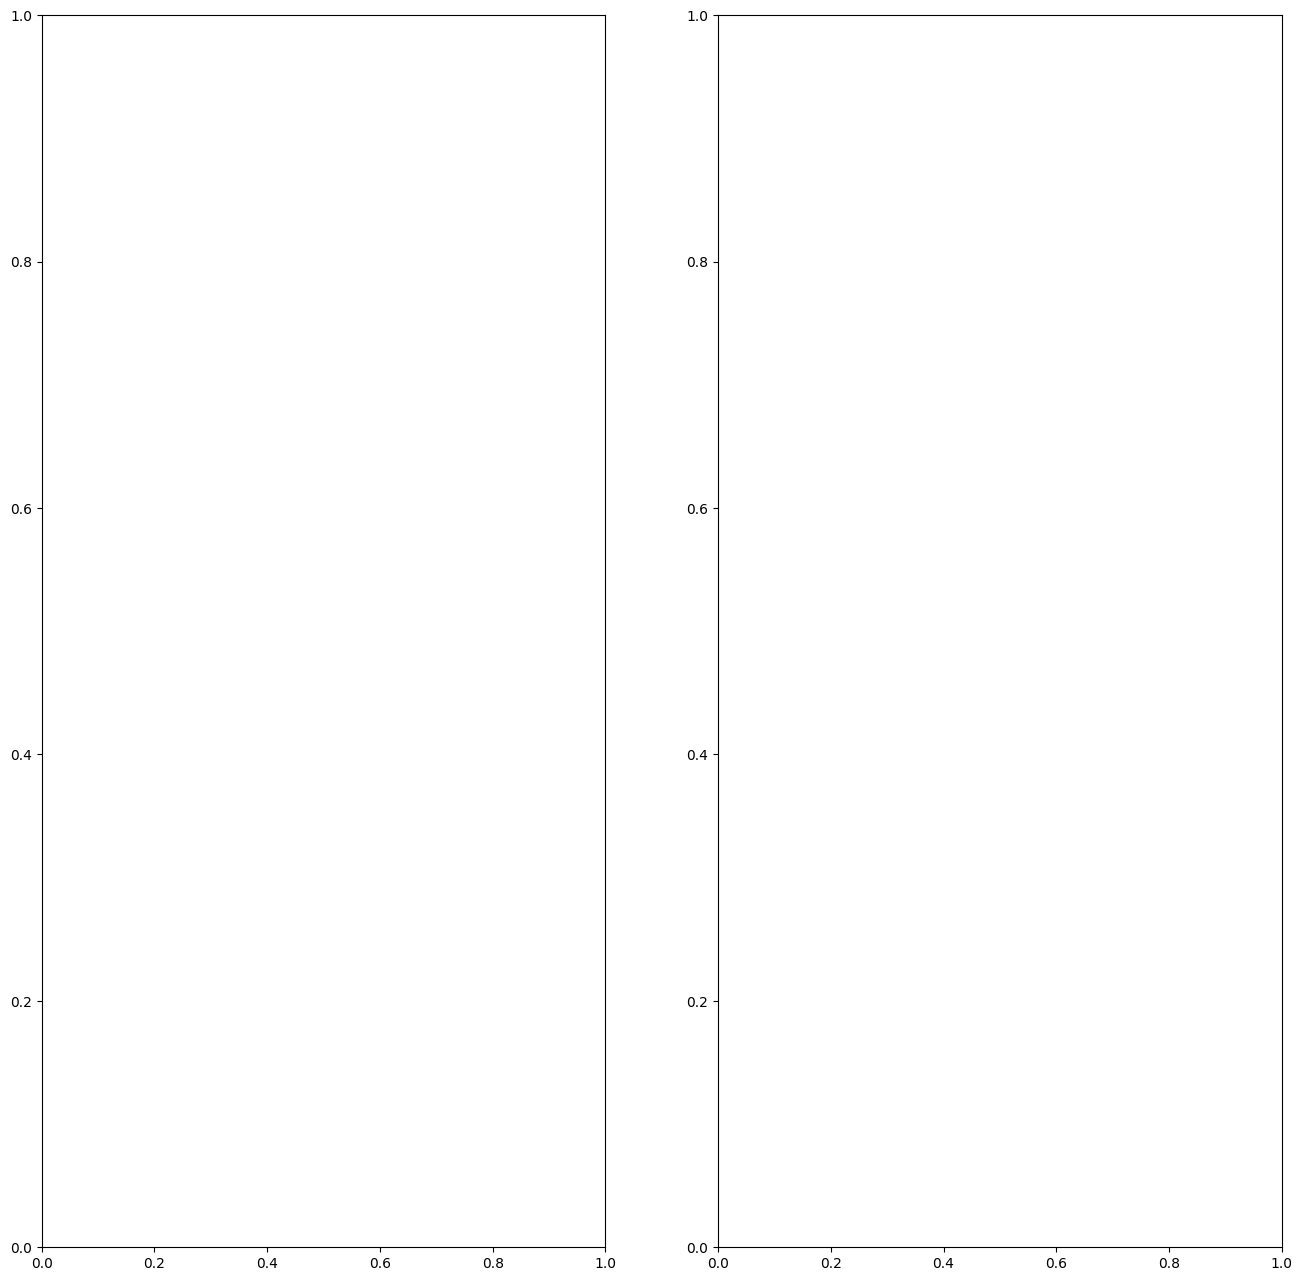

In [29]:
f, ax = plt.subplots(1, 2, figsize=(16, 16))

index = random.randint(0, len(data))
img_data = data[index]
image = img_data['image']
# masks = img_data['masks']
bboxes = img_data['bboxes']

empty = np.array([])
display_instances(image, empty, empty, empty, empty, show_mask=False, show_bbox=False, ax=ax[0])

if len(bboxes) > 0:
    boxes = np.stack([b[:4] for b in bboxes], axis=0)
    box_classes = np.array([b[-2] for b in bboxes])
    mask_indices = np.array([b[-1] for b in bboxes])
    show_masks = np.stack(masks, axis=-1)[..., mask_indices]
    class_names = {k: data.coco.cats[k]['name'] for k in data.coco.cats.keys()}
    display_instances(image, boxes, show_masks, box_classes, class_names, show_bbox=True, ax=ax[1])
else:
    display_instances(image, empty, empty, empty, empty, show_mask=False, show_bbox=False, ax=ax[1])